In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

### 데이터 전처리
1. 피처 의미 설명
2. 성능 평가 함수 정의
3. 범주형 변수 one-hot encoding
4. train test split

In [3]:
# 데이터 불러오기
df = pd.read_csv('heart_disease.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67,0,0,198,461,1,0,185,0,1.9,2,2,0,1
1,57,0,2,142,293,1,1,159,1,4.7,0,1,2,0
2,43,1,3,113,217,1,1,155,1,2.2,2,2,1,1
3,71,1,2,179,478,0,1,198,1,5.9,2,2,2,0
4,36,1,2,185,184,1,0,187,1,6.0,0,3,0,1


In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.00000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000
mean,53.678000,0.474000,1.438000,146.898000,347.624000,0.522000,0.96200,138.46800,0.506000,3.19300,1.054000,2.040000,1.026000,0.462000
std,14.127898,0.499824,1.093869,31.160963,130.039992,0.500016,0.81356,38.31743,0.500465,1.76438,0.812653,1.416479,0.806613,0.499053
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.00000,71.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,0.000000,0.000000,119.000000,236.000000,0.000000,0.00000,107.75000,0.000000,1.70000,0.000000,1.000000,0.000000,0.000000
50%,54.000000,0.000000,1.000000,147.000000,350.000000,1.000000,1.00000,139.00000,1.000000,3.20000,1.000000,2.000000,1.000000,0.000000
75%,65.000000,1.000000,2.000000,175.000000,461.000000,1.000000,2.00000,172.00000,1.000000,4.80000,2.000000,3.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,563.000000,1.000000,2.00000,202.00000,1.000000,6.20000,2.000000,4.000000,2.000000,1.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       500 non-null    int64  
 1   sex       500 non-null    int64  
 2   cp        500 non-null    int64  
 3   trestbps  500 non-null    int64  
 4   chol      500 non-null    int64  
 5   fbs       500 non-null    int64  
 6   restecg   500 non-null    int64  
 7   thalach   500 non-null    int64  
 8   exang     500 non-null    int64  
 9   oldpeak   500 non-null    float64
 10  slope     500 non-null    int64  
 11  ca        500 non-null    int64  
 12  thal      500 non-null    int64  
 13  target    500 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 54.8 KB


### 각 피처의 의미 설명
#### 1. 범주형 피처
sex : 성별   
cp : 흉통 유형     
fbs : 공복 혈당 수치가 120 mg/dl 초과인지 여부   
restecg : 안정 시 심전도 결과(0 정상, 1 ST-T파 이상, 2 좌심실 비대)   
exang : 운동 유발성 협심증 유무   
slope : 심전도의 최대 운동 시 ST 구간의 기울기   
thal : 탈륨 겸사 결과    

#### 2. 연속형 피처   
trestbps : 안정 시 혈압   
chol : 혈청 콜레스테롤 수치     
thalach : 최대 심박수   
oldpeak : 운동으로 인해 유발된 ST 하강 정도   
ca : 주요 혈관 개수

In [6]:
# 성능 평가 함수 정의
# precision, recall, f1-score 출력
def model_performance(y_pred, y_test, y_proba):
    """모델의 성능 지표를 확인하고, 화면에 출력한다.

        Args:
        y_pred : 모델이 예측한 값
        y_test : 실제값
        y_proba : 모델이 내부적으로 계산한 1번 클래스일 확률

    Returns:
        None
    """
    # 지표 계산
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    # 결과 딕셔너리 생성
    metrics = {
        "Precision": round(precision, 4),
        "Recall   ": round(recall, 4),
        "F1-Score ": round(f1, 4),
        "ROC-AUC  ": round(roc_auc, 4)
    }
    
    # 출력
    for key, val in metrics.items():
        print(f"{key}: {val}")

In [7]:
# 범주형 변수 one-hot encoding
# 애초에 0/1의 값을 가지는 피처는 인코딩할 필요가 없으므로 3개 이상 변수만 리스트로 묶어주었다
category_cols = ['cp', 'restecg', 'slope', 'thal']

df = pd.get_dummies(
    df, 
    columns=category_cols, 
    drop_first=True, 
    dtype=int
)

df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_1,thal_2
0,67,0,198,461,1,185,0,1.9,2,1,0,0,0,0,0,0,1,0,0
1,57,0,142,293,1,159,1,4.7,1,0,0,1,0,1,0,0,0,0,1
2,43,1,113,217,1,155,1,2.2,2,1,0,0,1,1,0,0,1,1,0
3,71,1,179,478,0,198,1,5.9,2,0,0,1,0,1,0,0,1,0,1
4,36,1,185,184,1,187,1,6.0,3,1,0,1,0,0,0,0,0,0,0


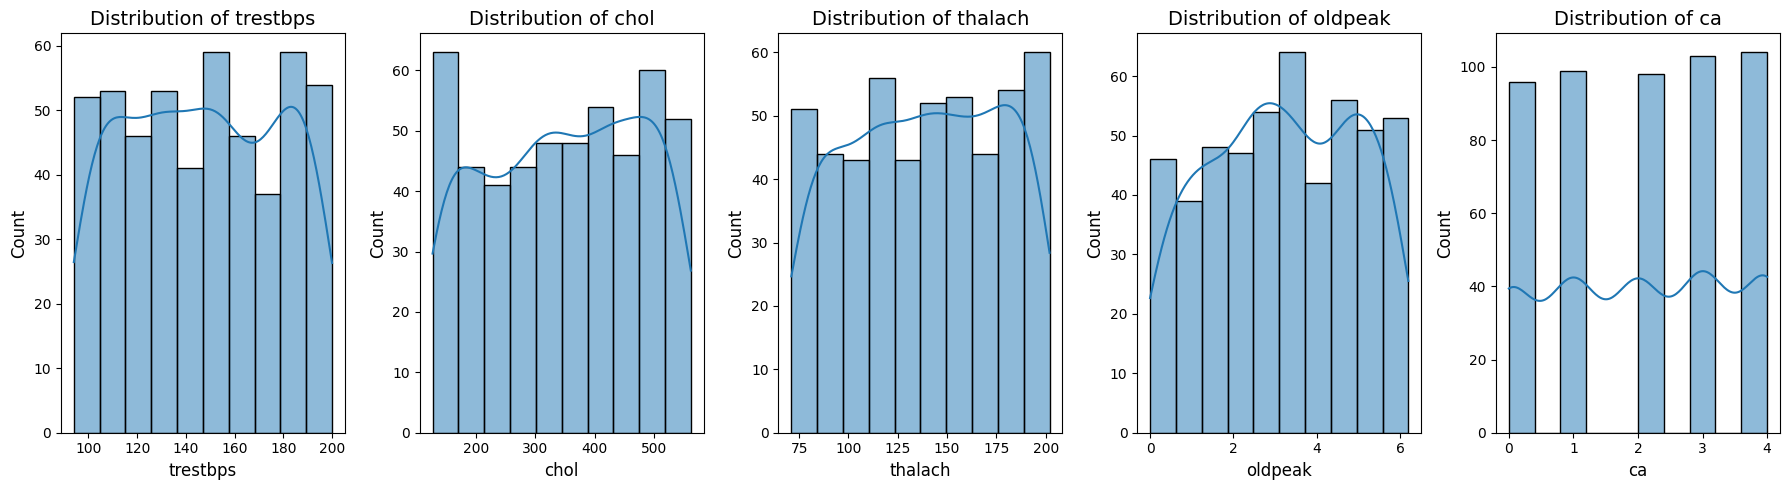

In [8]:
# 연속형 피처 분포 확인 -> 정규분포보다는 균등분포에 가까움
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화할 연속형 피처 리스트 지정
numerical_cols = ['trestbps', 'chol', 'thalach', 'oldpeak', 'ca']


# 1행 5열로 5개의 그래프 배치
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(18, 5))

# 반복문을 돌며 각 피처의 분포를 히스토그램+KDE 곡선으로 그리기
for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)

# 4. 그래프 간격 조절 및 출력
plt.tight_layout()
plt.show()

In [9]:
# X, y 분리
X = df.drop(columns=['target'])
y = df['target']

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y  # train, test 데이터셋에서 각각 0:1 비율을 똑같이 유지
)

### 로지스틱 회귀로 모델 학습

In [10]:
# 로지스틱 회귀로 초기 모델 학습
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
# max_iter : fit 과정에서 내부적으로 gradient descent를 실행할 때, 반복 횟수를 최대 몇 번으로 할 것인지 설정

lr_model.fit(X_train, y_train)

y_pred_lr_first = lr_model.predict(X_test)  
y_proba_lr_first = lr_model.predict_proba(X_test)[:, 1]  # 1일 확률값 (ROC-AUC 계산용)

model_performance(y_pred_lr_first, y_test, y_proba_lr_first)

Precision: 0.4643
Recall   : 0.3768
F1-Score : 0.416
ROC-AUC  : 0.4917


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Naive Bayes로 모델 학습

In [11]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

y_pred_nb = lr_model.predict(X_test)  
y_proba_nb = lr_model.predict_proba(X_test)[:, 1]  # 1일 확률값 (ROC-AUC 계산용)

model_performance(y_pred_nb, y_test, y_proba_nb)


Precision: 0.4643
Recall   : 0.3768
F1-Score : 0.416
ROC-AUC  : 0.4917


### 결과 해석
두 모델 모두 전반적인 수치가 낮게 나오고 ROC-AUC는 무작위로 맞추는 모델보다도 못한 수준이라 어느 점을 보완하면 좋을지 잘 감이 잡히지 않음. 